# Week 3 · Task 4 — A naive Bayes text classifier, from scratch

**Roadmap task:** *Build a naive Bayes text classifier — it is literally this week's mathematics, applied.*

The classifier is in `mathkit/naive_bayes.py` (~60 lines of real logic). It is tested against scikit-learn's `MultinomialNB` in `tests/test_naive_bayes.py` — the predicted probabilities agree to 10 decimal places.

**Data:** the *SMS Spam Collection* — 5,574 real text messages labelled `ham` (normal) or `spam`. Almeida, T.A., Gómez Hidalgo, J.M., Yamakami, A. (2011), UCI Machine Learning Repository, CC BY 4.0. Stored in `data/sms_spam.tsv`.

**What this notebook shows**

1. The maths: Bayes' theorem + one "naive" assumption + counting.
2. A tiny example worked completely by hand.
3. Training on real SMS messages and measuring it honestly (against a do-nothing baseline).
4. Checking it against scikit-learn.
5. Looking inside: which words scream "spam", and *why* one message was classified the way it was.
6. Tuning the smoothing parameter **without cheating** (using a validation set, not the test set).
7. What's wrong with it.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import numpy as np
import matplotlib.pyplot as plt
from mathkit.naive_bayes import MultinomialNaiveBayes, tokenize

FIG = pathlib.Path("figures"); FIG.mkdir(exist_ok=True)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})
np.set_printoptions(suppress=True, precision=4)

## 1. The maths

We want $P(\text{spam}\mid\text{message})$. Bayes' theorem:

$$P(\text{spam}\mid\text{msg}) = \frac{P(\text{msg}\mid\text{spam})\;P(\text{spam})}{P(\text{msg})}$$

* $P(\text{spam})$ — the **prior**: just the fraction of training messages that are spam.
* $P(\text{msg}\mid\text{spam})$ — the **likelihood**. Impossible to estimate directly: almost every message is unique, so we've never seen *this exact message* before.

**The naive assumption:** pretend that, once you know the class, each word is drawn independently. Then the likelihood factorises into per-word pieces:

$$P(\text{msg}\mid c) = \prod_{w \in \text{msg}} P(w\mid c)^{\,\text{count}(w)}$$

And each $P(w\mid c)$ is just **counting**, with $+\alpha$ smoothing (so a word never seen in spam doesn't make $P(\text{msg}\mid\text{spam}) = 0$ and veto everything else):

$$P(w\mid c) = \frac{\text{count of } w \text{ in class } c \;+\; \alpha}{\text{total words in class } c \;+\; \alpha\,|V|}$$

where $|V|$ is the vocabulary size. Finally, multiplying hundreds of small probabilities underflows to 0 on a computer, so we take **logs** and add instead:

$$\log P(c\mid\text{msg}) = \underbrace{\log P(c) + \sum_w \text{count}(w)\,\log P(w\mid c)}_{\text{score for class } c} \;-\; \log P(\text{msg})$$

We pick the class with the bigger score. $P(\text{msg})$ is the same for both classes, so for *choosing* we can ignore it; for *probabilities* we normalise with the log-sum-exp trick.

## 2. A tiny example — by hand

Training set: spam = {"free win", "free cash"}, ham = {"hi friend", "hi"}. Vocabulary $V$ = {cash, free, friend, hi, win}, so $|V| = 5$. Use $\alpha = 1$.

| | spam (4 words) | ham (3 words) |
|---|---|---|
| prior | 2/4 = 1/2 | 2/4 = 1/2 |
| $P(\text{free}\mid c)$ | (2+1)/(4+5) = **1/3** | (0+1)/(3+5) = **1/8** |
| $P(\text{hi}\mid c)$ | (0+1)/(4+5) = 1/9 | (2+1)/(3+5) = 3/8 |

New message: **"free"**.

$$P(\text{spam}\mid\text{"free"}) = \frac{\tfrac12\cdot\tfrac13}{\tfrac12\cdot\tfrac13 + \tfrac12\cdot\tfrac18} = \frac{1/6}{1/6 + 1/16} = \frac{8}{11} \approx 0.727$$

In [2]:
toy = MultinomialNaiveBayes(alpha=1).fit(["free win", "free cash", "hi friend", "hi"], ["spam", "spam", "ham", "ham"])
print("classes:", toy.classes_, "  vocabulary:", toy.vocab_)
print("P(word | class) table:\n", np.exp(toy.feature_log_prob_))
print("P(spam | 'free')   =", toy.predict_proba(["free"])[0, 1].round(4), "   (by hand: 8/11 =", round(8 / 11, 4), ")")
print("P(spam | 'hi free') =", toy.predict_proba(["hi free"])[0, 1].round(4))

classes: ['ham' 'spam']   vocabulary: {'cash': 0, 'free': 1, 'friend': 2, 'hi': 3, 'win': 4}
P(word | class) table:
 [[0.125  0.125  0.25   0.375  0.125 ]
 [0.2222 0.3333 0.1111 0.1111 0.2222]]
P(spam | 'free')   = 0.7273    (by hand: 8/11 = 0.7273 )
P(spam | 'hi free') = 0.4414


## 3. Real data: 5,574 text messages

In [3]:
lines = (pathlib.Path.cwd().parent / "data" / "sms_spam.tsv").read_text(encoding="utf-8").splitlines()
labels = np.array([l.split("\t", 1)[0] for l in lines])
texts = np.array([l.split("\t", 1)[1] for l in lines], dtype=object)
print(f"{len(texts):,} messages   spam = {np.mean(labels == 'spam'):.1%}   ham = {np.mean(labels == 'ham'):.1%}")
for lab in ["ham", "spam"]:
    print(f"\n{lab.upper()} examples:")
    for t in texts[labels == lab][:3]:
        print("   ", t[:110])

5,574 messages   spam = 13.4%   ham = 86.6%

HAM examples:
    Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat..
    Ok lar... Joking wif u oni...
    U dun say so early hor... U c already then say...

SPAM examples:
    Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question
    FreeMsg Hey there darling it's been 3 week's now and no word back! I'd like some fun you up for it still? Tb o
    WINNER!! As a valued network customer you have been selected to receivea £900 prize reward! To claim call 0906


**Split before doing anything else.** 60% train, 20% validation (for choosing $\alpha$), 20% test (touched **once**, at the very end). The split is stratified — each part keeps the same 13% spam rate.

In [4]:
rng = np.random.default_rng(0)
idx_train, idx_val, idx_test = [], [], []
for lab in ["ham", "spam"]:
    idx = rng.permutation(np.flatnonzero(labels == lab))
    a, b = int(0.6 * len(idx)), int(0.8 * len(idx))
    idx_train += list(idx[:a]); idx_val += list(idx[a:b]); idx_test += list(idx[b:])
X_tr, y_tr = list(texts[idx_train]), labels[idx_train]
X_va, y_va = list(texts[idx_val]), labels[idx_val]
X_te, y_te = list(texts[idx_test]), labels[idx_test]
print(f"train {len(y_tr)}  |  validation {len(y_va)}  |  test {len(y_te)}")

train 3344  |  validation 1114  |  test 1116


## 4. Choose α on the validation set (not the test set!)

Tuning on the test set and then reporting the test score is a quiet lie — you'd be reporting the best of many tries on the same data. (Week 10 measures exactly how big that lie is.)

In [5]:
def scores(y_true, y_pred, positive="spam"):
    tp = np.sum((y_pred == positive) & (y_true == positive))
    fp = np.sum((y_pred == positive) & (y_true != positive))
    fn = np.sum((y_pred != positive) & (y_true == positive))
    precision = tp / (tp + fp) if tp + fp else 0.0
    recall = tp / (tp + fn) if tp + fn else 0.0
    f1 = 2 * precision * recall / (precision + recall) if precision + recall else 0.0
    return {"accuracy": np.mean(y_true == y_pred), "precision": precision, "recall": recall, "f1": f1}

alphas = [0.01, 0.03, 0.1, 0.3, 1, 3, 10]
val_f1 = []
for a in alphas:
    m = MultinomialNaiveBayes(alpha=a).fit(X_tr, y_tr)
    s = scores(y_va, m.predict(X_va)); val_f1.append(s["f1"])
    print(f"alpha={a:<5}  validation: accuracy {s['accuracy']:.4f}  precision {s['precision']:.3f}  recall {s['recall']:.3f}  F1 {s['f1']:.3f}")
best_alpha = alphas[int(np.argmax(val_f1))]
print(f"\nchosen alpha = {best_alpha}  (best validation F1)")
if best_alpha == alphas[0]:
    print("note: the best alpha is at the EDGE of the grid - in real work, extend the grid lower and check again.")

alpha=0.01   validation: accuracy 0.9883  precision 0.993  recall 0.919  F1 0.955


alpha=0.03   validation: accuracy 0.9874  precision 0.986  recall 0.919  F1 0.951


alpha=0.1    validation: accuracy 0.9865  precision 0.979  recall 0.919  F1 0.948


alpha=0.3    validation: accuracy 0.9865  precision 0.979  recall 0.919  F1 0.948
alpha=1      validation: accuracy 0.9847  precision 0.978  recall 0.906  F1 0.941


alpha=3      validation: accuracy 0.9740  precision 0.976  recall 0.826  F1 0.895


alpha=10     validation: accuracy 0.9479  precision 1.000  recall 0.611  F1 0.758

chosen alpha = 0.01  (best validation F1)
note: the best alpha is at the EDGE of the grid - in real work, extend the grid lower and check again.


## 5. Final model → test set, once

vocabulary size: 7,987 words

                       accuracy  precision  recall   F1
always say ham         0.8656    0.000     0.000   0.000
naive Bayes (ours)     0.9866    0.953     0.947   0.950


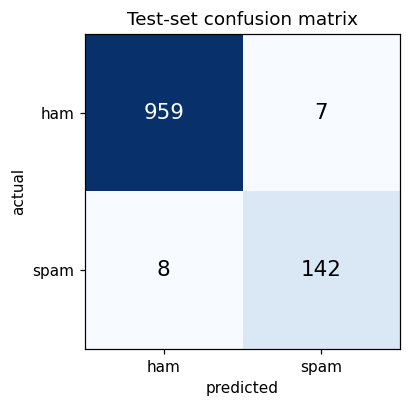

In [6]:
nb = MultinomialNaiveBayes(alpha=best_alpha).fit(X_tr + X_va, np.concatenate([y_tr, y_va]))   # refit on train+val
pred = nb.predict(X_te)
s = scores(y_te, pred)
baseline = scores(y_te, np.full(len(y_te), "ham"))
print(f"vocabulary size: {len(nb.vocab_):,} words")
print(f"\n{'':22s} accuracy  precision  recall   F1")
print(f"{'always say ham':22s} {baseline['accuracy']:.4f}    {baseline['precision']:.3f}     {baseline['recall']:.3f}   {baseline['f1']:.3f}")
print(f"{'naive Bayes (ours)':22s} {s['accuracy']:.4f}    {s['precision']:.3f}     {s['recall']:.3f}   {s['f1']:.3f}")

cm = np.array([[np.sum((y_te == t) & (pred == p)) for p in ["ham", "spam"]] for t in ["ham", "spam"]])
fig, ax = plt.subplots(figsize=(4.2, 3.8))
ax.imshow(cm, cmap="Blues"); ax.grid(False)
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=14, color="white" if cm[i, j] > cm.max() / 2 else "black")
ax.set_xticks([0, 1], ["ham", "spam"]); ax.set_yticks([0, 1], ["ham", "spam"])
ax.set_xlabel("predicted"); ax.set_ylabel("actual"); ax.set_title("Test-set confusion matrix")
fig.tight_layout(); fig.savefig(FIG / "w3_nb_confusion.png", dpi=150); plt.show()

**Read this carefully.** A model that *always* says "ham" already gets ~87% accuracy — and catches zero spam. That's why accuracy alone is a terrible metric when one class is rare (Week 12's big lesson). Precision and recall for the *spam* class tell the real story:

* **precision** = of the messages we flagged as spam, how many really were?
* **recall** = of the real spam, how much did we catch?

## 6. Check against scikit-learn

Same count matrix in, same probabilities out. (If scikit-learn isn't installed, this cell just says so.)

In [7]:
try:
    from sklearn.naive_bayes import MultinomialNB
    ref = MultinomialNB(alpha=best_alpha).fit(nb.transform(X_tr + X_va), np.concatenate([y_tr, y_va]))
    diff = np.max(np.abs(ref.predict_proba(nb.transform(X_te)) - nb.predict_proba(X_te)))
    same = np.mean(ref.predict(nb.transform(X_te)) == pred)
    print(f"max |our probability − sklearn probability| = {diff:.2e}")
    print(f"predictions identical on {same:.1%} of test messages")
except ImportError:
    print("scikit-learn not installed - run `pip install scikit-learn` to see this comparison.")

max |our probability − sklearn probability| = 1.42e-14
predictions identical on 100.0% of test messages


## 7. Look inside the model

Which words push hardest toward spam? The model's evidence for a word is the **log-ratio** $\log\dfrac{P(w\mid\text{spam})}{P(w\mid\text{ham})}$. Positive = spammy.

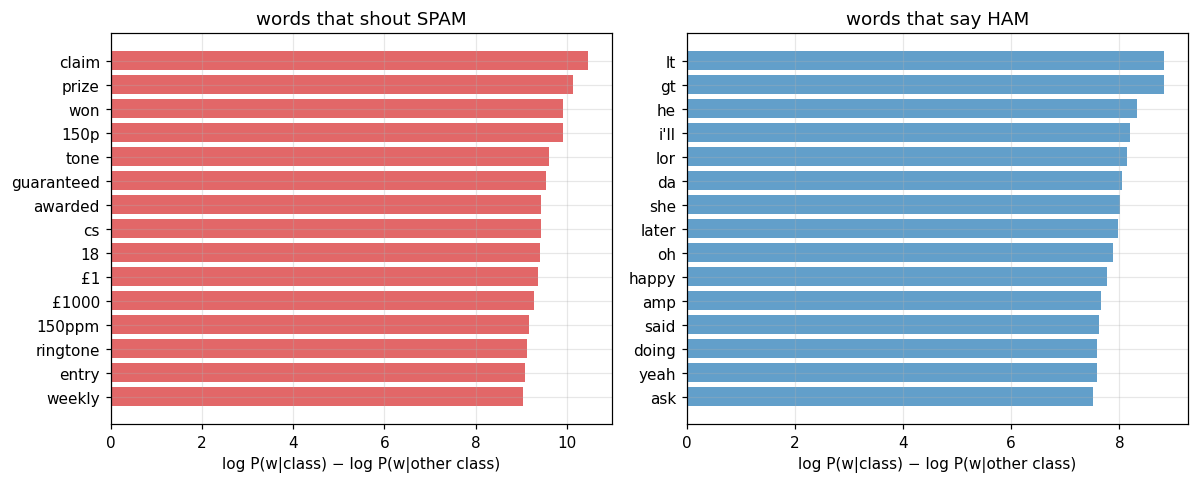

In [8]:
top_spam = nb.most_indicative_words("spam", k=15)
top_ham = nb.most_indicative_words("ham", k=15)
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, words, color, title in [(axes[0], top_spam, "tab:red", "words that shout SPAM"),
                                (axes[1], top_ham, "tab:blue", "words that say HAM")]:
    w, r = zip(*words)
    ax.barh(range(len(w))[::-1], r, color=color, alpha=0.7)
    ax.set_yticks(range(len(w))[::-1], w); ax.set_xlabel("log P(w|class) − log P(w|other class)"); ax.set_title(title)
fig.tight_layout(); fig.savefig(FIG / "w3_nb_words.png", dpi=150); plt.show()

Mostly sensible: claim, prize, won, guaranteed, "£1000", premium-rate charges like "150p" → spam. Everyday chat words (i'll, later, happy, yeah, "lor"/"da" — Singaporean/Indian English slang in this dataset) → ham.

**But look at the top two ham words: "lt" and "gt".** Those aren't words — they come from `&lt;#&gt;`, an HTML-escaped placeholder that appears in 214 messages of this dataset, **every single one of them ham** (check: `grep` the file). It looks like something replaced content during the dataset's preparation. The model has learned an **artifact of how the data was collected**, not something about spam. On new data without that artifact, this "evidence" is worthless. Always read the top features — this is how you find leaks and artifacts.

**Explaining one prediction.** Because the score is a *sum* over words, we can show exactly how much each word contributed. This is your first taste of model explanation (SHAP in Week 15 generalises this idea).

In [9]:
def explain(model, message):
    spam, ham = list(model.classes_).index("spam"), list(model.classes_).index("ham")
    total = model.class_log_prior_[spam] - model.class_log_prior_[ham]
    print(f'message: "{message}"')
    print(f"  {'prior (spam is rarer)':<24}{total:+.2f}")
    for w in tokenize(message):
        j = model.vocab_.get(w)
        if j is None:
            print(f"  {w:<24}  (never seen in training - ignored)"); continue
        c = model.feature_log_prob_[spam, j] - model.feature_log_prob_[ham, j]
        total += c
        print(f"  {w:<24}{c:+.2f}")
    p = model.predict_proba([message])[0, spam]
    print(f"  {'TOTAL log-odds':<24}{total:+.2f}   ->  P(spam) = {p:.4f}\n")

explain(nb, "URGENT! You have won a FREE prize, call now to claim")
explain(nb, "Hey are we still meeting for lunch later?")
explain(nb, "Call me when you get free")

message: "URGENT! You have won a FREE prize, call now to claim"
  prior (spam is rarer)   -1.87
  urgent                  +3.21
  you                     -0.51
  have                    +0.11
  won                     +9.92
  a                       +0.33
  free                    +2.59
  prize                   +10.13
  call                    +1.76
  now                     +0.89
  to                      +0.51
  claim                   +10.46
  TOTAL log-odds          +37.52   ->  P(spam) = 1.0000

message: "Hey are we still meeting for lunch later?"
  prior (spam is rarer)   -1.87
  hey                     -1.49
  are                     -0.38
  we                      -0.62
  still                   -1.73
  meeting                 -6.74
  for                     +0.31
  lunch                   -6.91
  later                   -7.97
  TOTAL log-odds          -27.40   ->  P(spam) = 0.0000

message: "Call me when you get free"
  prior (spam is rarer)   -1.87
  call                    

The total log-odds converts to a probability with the sigmoid: $P(\text{spam}) = 1/(1+e^{-\text{log-odds}})$ — the **same function** as logistic regression in Week 11. Naive Bayes and logistic regression are close cousins: both are linear in the word counts. Naive Bayes gets its weights by counting; logistic regression learns them by gradient descent.

## 8. What's wrong with it (limitations)

1. **The naive assumption is false.** "free" and "prize" appear together far more than chance. Naive Bayes counts that evidence twice, so its probabilities are **over-confident** — look how they pile up at 0 and 1 below. The *ranking* is good; the *probabilities* shouldn't be trusted as-is (calibration, Week 12).
2. **Word order is ignored.** "not good" and "good, not" look identical.
3. **Unseen words are thrown away.** New spam tricks (e.g. "fr33") are invisible.
4. **One dataset, 2011, UK SMS.** It would not transfer directly to today's messages.

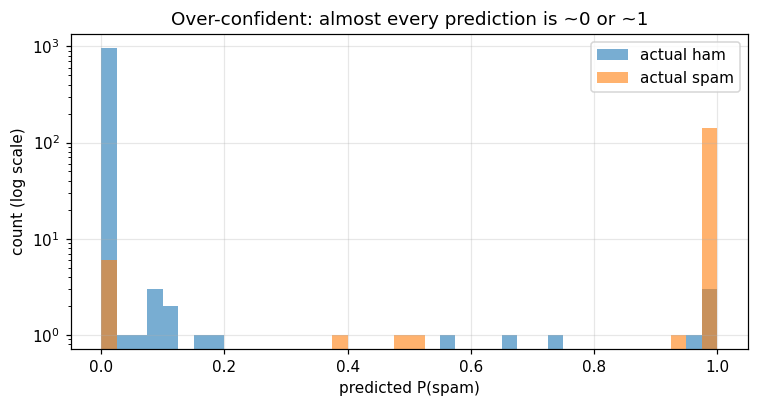

96.8% of test predictions are below 1% or above 99%


In [10]:
p_spam = nb.predict_proba(X_te)[:, list(nb.classes_).index("spam")]
fig, ax = plt.subplots(figsize=(7, 3.8))
ax.hist(p_spam[y_te == "ham"], bins=40, range=(0, 1), alpha=0.6, label="actual ham", log=True)
ax.hist(p_spam[y_te == "spam"], bins=40, range=(0, 1), alpha=0.6, label="actual spam", log=True)
ax.set_xlabel("predicted P(spam)"); ax.set_ylabel("count (log scale)")
ax.set_title("Over-confident: almost every prediction is ~0 or ~1"); ax.legend()
fig.tight_layout(); fig.savefig(FIG / "w3_nb_confidence.png", dpi=150); plt.show()
print(f"{np.mean((p_spam < 0.01) | (p_spam > 0.99)):.1%} of test predictions are below 1% or above 99%")

Let's also look at the mistakes — always read your errors:

In [11]:
wrong = np.flatnonzero(pred != y_te)
for i in wrong[:8]:
    print(f"actual {y_te[i]:<4}  predicted {pred[i]:<4}  P(spam)={p_spam[i]:.3f}  | {X_te[i][:95]}")

actual ham   predicted spam  P(spam)=0.962  | Unlimited texts. Limited minutes.
actual ham   predicted spam  P(spam)=0.557  | How much it will cost approx . Per month.
actual ham   predicted spam  P(spam)=0.652  | Yes we are chatting too.
actual ham   predicted spam  P(spam)=0.740  | K:)eng rocking in ashes:)
actual ham   predicted spam  P(spam)=0.999  | Gettin rdy to ship comp
actual ham   predicted spam  P(spam)=0.998  | Yavnt tried yet and never played original either
actual ham   predicted spam  P(spam)=0.992  | Whens your radio show?
actual spam  predicted ham   P(spam)=0.000  | Oh my god! I've found your number again! I'm so glad, text me back xafter this msgs cst std ntw


## 9. Your turn

1. By hand, using the toy table in section 2: compute $P(\text{spam}\mid\text{"hi free"})$. Check against the printed value.
2. Change the tokenizer so all numbers become the single token `<num>`. Does the test F1 improve? (Choose on **validation**, report test once.)
3. Set `alpha` to 1e-9 (almost no smoothing) and feed it a message containing a word that only ever appeared in ham. What happens to P(spam), and why?
4. **Explain out loud:** "Why is it called *naive* Bayes, and why does it still work well for spam?"